# 12. Ansambl (ensemble) metode

## Šta su ansambl metode

Ansambl metode **kombinuju više modela u jedan prediktor**:

$$\hat y = f\big(h_1(x), h_2(x), \dots, h_M(x)\big)$$

gde su $h_i$ pojedinačni modeli.

> Kao kod više stručnjaka — pojedinačno mogu da pogreše, ali zajedno često donesu bolju
> odluku.

## Zašto kombinovanje poboljšava rezultate

- pojedinačni modeli prave **različite** greške
- greške se pri kombinovanju **međusobno poništavaju**
- ansambl smanjuje nestabilnost predikcije
- posebno efikasno kod **nestabilnih** modela (npr. stabla odlučivanja)

> **Ključni uslov: raznolikost.** Ansambl radi **samo ako modeli nisu identični**.
> Ako svi modeli greše isto, ansambl ne pomaže.

## Teme

Majority Voting · Bagging · Boosting · Gradient Boosting · Random Forests · Stacking

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
from sklearn.ensemble import (VotingClassifier, BaggingClassifier, RandomForestClassifier,
                              ExtraTreesClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.datasets import load_breast_cancer, make_classification
from xgboost import XGBClassifier

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42

bc = load_breast_cancer()
X, y = bc.data, bc.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RS, stratify=y)
cv = StratifiedKFold(5, shuffle=True, random_state=RS)
print(f"Podaci: {X.shape[0]} uzoraka x {X.shape[1]} obelezja, 2 klase")

Podaci: 569 uzoraka x 30 obelezja, 2 klase


## Majority Voting (većinsko glasanje)

Više klasifikatora se trenira na **istom** skupu, svaki daje predikciju, a finalna odluka
se donosi **većinskim glasanjem**. Svi modeli imaju jednaku težinu.

### Zašto to radi — matematika

Pretpostavke: $n$ **nezavisnih** klasifikatora, svaki sa greškom $\varepsilon$, greške
**nekorelirane**, binarni problem, i **svaki bolji od slučajnog**: $\varepsilon < 0.5$.

Ansambl greši **samo ako većina modela pogreši**, pa se greška računa kumulativnom
verovatnoćom binomne raspodele:

$$\varepsilon_{ens} = \sum_{k=\lceil n/2 \rceil}^{n} \binom{n}{k}\, \varepsilon^k (1-\varepsilon)^{n-k}$$

**Primer sa predavanja:** $n = 11$, $\varepsilon = 0.25$ → $\varepsilon_{ens} = 0.034$

Ako 11 modela pojedinačno greši u 25% slučajeva, verovatnoća da **bar 6** pogreši
istovremeno je samo **3,4%**. To je ogroman pad greške.

| $\varepsilon$ | efekat ansambla |
|---|---|
| $< 0.5$ | greška ansambla je **manja** |
| $= 0.5$ | nema koristi |
| $> 0.5$ | ansambl **pogoršava** rezultat |

**Zato je uslov $\varepsilon < 0.5$ ključan.**

Primer sa predavanja: n=11, eps=0.25
   greska ansambla = 0.0343   (vs 0.25 pojedinacno)



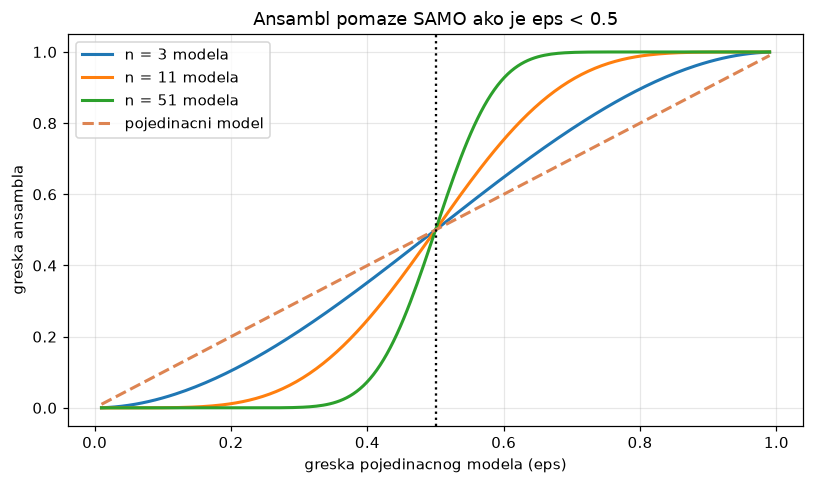

   eps       n=3      n=11      n=51
   0.1    0.0280    0.0003    0.0000
  0.25    0.1562    0.0343    0.0001
  0.45    0.4253    0.3669    0.2359
   0.5    0.5000    0.5000    0.5000
   0.6    0.6480    0.7535    0.9265


In [2]:
def greska_ansambla(n, eps):
    'Kumulativna verovatnoca da BAR polovina od n modela pogresi.'
    k_min = int(np.ceil(n / 2))
    return sum(binom.pmf(k, n, eps) for k in range(k_min, n + 1))

print(f"Primer sa predavanja: n=11, eps=0.25")
print(f"   greska ansambla = {greska_ansambla(11, 0.25):.4f}   (vs {0.25} pojedinacno)\n")

eps = np.linspace(0.01, 0.99, 200)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for n in (3, 11, 51):
    ax.plot(eps, [greska_ansambla(n, e) for e in eps], lw=2, label=f"n = {n} modela")
ax.plot(eps, eps, "--", color="#DD8452", lw=2, label="pojedinacni model")
ax.axvline(0.5, color="k", ls=":", lw=1.5)
ax.set_xlabel("greska pojedinacnog modela (eps)"); ax.set_ylabel("greska ansambla")
ax.set_title("Ansambl pomaze SAMO ako je eps < 0.5"); ax.legend()
plt.tight_layout(); plt.show()

print(f"{'eps':>6} {'n=3':>9} {'n=11':>9} {'n=51':>9}")
for e in (0.1, 0.25, 0.45, 0.5, 0.6):
    print(f"{e:>6} {greska_ansambla(3,e):>9.4f} {greska_ansambla(11,e):>9.4f} {greska_ansambla(51,e):>9.4f}")

### Hard voting vs. soft voting

| | šta model daje | formula |
|---|---|---|
| **Hard voting** | samo **klasu**, bez sigurnosti | $\hat y = \text{mode}\big(h_1(x), \dots, h_n(x)\big)$ |
| **Soft voting** | **verovatnoće** klasa | $\hat y = \arg\max_j \sum_{i=1}^{n} w_i \, p_{i,j}$ |

Soft voting uzima u obzir **koliko je model siguran** u odluku, pa je obično bolji.

**Primer soft votinga:**
$h_1 \to (0.9, 0.1)$, $h_2 \to (0.8, 0.2)$, $h_3 \to (0.4, 0.6)$

$p(0) = 0.58$, $p(1) = 0.42$ → $\hat y = 0$

Kod hard votinga bi $h_1$ i $h_2$ glasali za 0, $h_3$ za 1 → takođe 0, ali bez informacije
o sigurnosti.

In [3]:
h = np.array([[0.9, 0.1], [0.8, 0.2], [0.4, 0.6]])
soft = h.mean(axis=0)
hard = np.bincount(h.argmax(axis=1), minlength=2)
print("Verovatnoce po modelu:")
for i, r in enumerate(h, 1): print(f"   h{i}(x) -> {r}")
print(f"\nSOFT voting: prosek = {soft.round(3)}  ->  klasa {soft.argmax()}")
print(f"HARD voting: glasovi = {hard.tolist()}  ->  klasa {hard.argmax()}")

Verovatnoce po modelu:
   h1(x) -> [0.9 0.1]
   h2(x) -> [0.8 0.2]
   h3(x) -> [0.4 0.6]

SOFT voting: prosek = [0.7 0.3]  ->  klasa 0
HARD voting: glasovi = [2, 1]  ->  klasa 0


In [4]:
c1 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
c2 = DecisionTreeClassifier(max_depth=5, random_state=RS)
c3 = make_pipeline(StandardScaler(), KNeighborsClassifier(7))

print(f"{'model':<26} {'CV tacnost':>12}")
print("-" * 40)
for ime, m in [("Logisticka regresija", c1), ("Stablo (dubina 5)", c2), ("kNN (k=7)", c3)]:
    print(f"{ime:<26} {cross_val_score(m, X, y, cv=cv).mean():>12.4f}")

for tip in ("hard", "soft"):
    v = VotingClassifier([("lr", c1), ("dt", c2), ("knn", c3)], voting=tip)
    print(f"{'Voting (' + tip + ')':<26} {cross_val_score(v, X, y, cv=cv).mean():>12.4f}")

model                        CV tacnost
----------------------------------------
Logisticka regresija             0.9737
Stablo (dubina 5)                0.9280


kNN (k=7)                        0.9649
Voting (hard)                    0.9649
Voting (soft)                    0.9561


## Bagging (Bootstrap Aggregating)

Treniramo **više istih modela** na različitim skupovima dobijenim **bootstrap
uzorkovanjem**. Pošto su modeli trenirani na malo drugačijim podacima, njihove greške se
razlikuju, a glasanje daje stabilniju predikciju.

> **Bagging ne menja model — menja podatke.**

### Bootstrap uzorkovanje

Uzorkovanje **sa vraćanjem**. Svaki bootstrap skup $D_i$ ima $m$ instanci (obično
$m = |D|$); neki primeri se ponavljaju, neki izostanu.

Verovatnoća da jedna instanca **ne bude** izabrana:

$$P(\text{nije izabrana}) = \left(1 - \frac{1}{m}\right)^{m} \xrightarrow{m \to \infty} \frac{1}{e} \approx 0.368$$

$$P(\text{izabrana bar jednom}) = 1 - \frac{1}{e} \approx 0.632$$

> U jednom bootstrap uzorku **~63%** instanci se pojavi bar jednom, a **~37%** ostane van —
> to su **out-of-bag (OOB)** instance, koje se mogu koristiti za besplatnu validaciju.

### Šta bagging smanjuje

| | efekat |
|---|---|
| **varijansa** | **smanjuje** — greške pojedinačnih modela se poništavaju |
| **bias** | **ne smanjuje značajno** — ako su svi modeli sistematski loši, bagging to ne popravlja |

Kod regresije se kombinuje **prosekom**, kod klasifikacije **glasanjem**.

In [5]:
m_vel = 1000
r = np.random.RandomState(RS)
uzorak = r.choice(m_vel, m_vel, replace=True)         # bootstrap: SA vracanjem
jedinstvenih = len(set(uzorak))

print(f"Bootstrap uzorak velicine {m_vel}:")
print(f"   jedinstvenih instanci : {jedinstvenih} ({jedinstvenih/m_vel:.1%})")
print(f"   out-of-bag            : {m_vel-jedinstvenih} ({1-jedinstvenih/m_vel:.1%})")
print(f"\nTeorijski: 1 - 1/e = {1-1/np.e:.4f} = {(1-1/np.e)*100:.1f}% se pojavi")
print(f"           1/e     = {1/np.e:.4f} = {100/np.e:.1f}% ostane OOB")

print(f"\n{'m':>8} {'udeo jedinstvenih':>20}")
for m in (10, 100, 1000, 10000):
    ud = np.mean([len(set(r.choice(m, m, replace=True)))/m for _ in range(30)])
    print(f"{m:>8} {ud:>20.4f}")

Bootstrap uzorak velicine 1000:
   jedinstvenih instanci : 615 (61.5%)
   out-of-bag            : 385 (38.5%)

Teorijski: 1 - 1/e = 0.6321 = 63.2% se pojavi
           1/e     = 0.3679 = 36.8% ostane OOB

       m    udeo jedinstvenih
      10               0.6400
     100               0.6290
    1000               0.6342


   10000               0.6326


In [6]:
stablo = DecisionTreeClassifier(random_state=RS)
bag = BaggingClassifier(stablo, n_estimators=100, oob_score=True, random_state=RS, n_jobs=-1)
bag.fit(Xtr, ytr)

print(f"Jedno stablo (bez ogranicenja): {cross_val_score(stablo, X, y, cv=cv).mean():.4f}")
print(f"Bagging od 100 stabala        : {cross_val_score(bag, X, y, cv=cv).mean():.4f}")
print(f"\nOOB score (besplatna validacija): {bag.oob_score_:.4f}")
print(f"Test tacnost                    : {bag.score(Xte, yte):.4f}")
print("-> OOB je dobra procena test tacnosti, bez izdvajanja posebnog skupa.")

Jedno stablo (bez ogranicenja): 0.9104


Bagging od 100 stabala        : 0.9543

OOB score (besplatna validacija): 0.9548
Test tacnost                    : 0.9474
-> OOB je dobra procena test tacnosti, bez izdvajanja posebnog skupa.


In [7]:
# bagging smanjuje VARIJANSU, ne bias — merenje
def varijansa_modela(napravi, n_puta=25):
    'Koliko se predikcije menjaju kada promenimo trening skup.'
    P = []
    for i in range(n_puta):
        a, _, c, _ = train_test_split(Xtr, ytr, test_size=0.35, random_state=i)
        P.append(napravi().fit(a, c).predict_proba(Xte)[:, 1])
    P = np.array(P)
    return P.var(axis=0).mean(), (P.mean(axis=0).round() != yte).mean()

for ime, f in [("jedno stablo", lambda: DecisionTreeClassifier(random_state=None)),
               ("bagging (50 stabala)", lambda: BaggingClassifier(
                   DecisionTreeClassifier(), n_estimators=50, n_jobs=-1))]:
    v, g = varijansa_modela(f)
    print(f"{ime:<24} varijansa predikcija = {v:.5f}, greska proseka = {g:.4f}")
print("\n-> Bagging drasticno smanjuje varijansu predikcija.")

jedno stablo             varijansa predikcija = 0.04080, greska proseka = 0.0585


bagging (50 stabala)     varijansa predikcija = 0.00461, greska proseka = 0.0526

-> Bagging drasticno smanjuje varijansu predikcija.


## Boosting

Za razliku od bagginga, gde su modeli **nezavisni**, kod boostinga se modeli treniraju
**sekvencijalno** — svaki novi model uči iz **grešaka prethodnih**.

| | **Bagging** | **Boosting** |
|---|---|---|
| treniranje | **nezavisno**, paralelno | **sekvencijalno** |
| smanjuje | **varijansu** | prvenstveno **bias** |
| težine modela | svi jednaki | **različite** |

### Dve glavne porodice

| | **AdaBoost** | **Gradient Boosting** |
|---|---|---|
| ideja | fokus na **teške** (pogrešno klasifikovane) uzorke | direktna **optimizacija funkcije gubitka** |
| kako | eksplicitno **menja težine uzoraka** | novi model uči **rezidual** (negativni gradijent) |
| greška | tačno / netačno | posmatra se **kontinuirano** |
| implementacije | `AdaBoostClassifier` | `GradientBoosting`, **XGBoost**, LightGBM, CatBoost |

AdaBoost je istorijski prvi i intuitivniji; Gradient Boosting je opštiji i danas dominantan.

### AdaBoost — algoritam

**1. Inicijalizacija.** Svakom uzorku ista težina:
$$w_1(i) = \frac{1}{n}, \qquad \sum_{i=1}^{n} w_1(i) = 1$$

**2. U svakoj iteraciji $r$:**

**(a)** Trenira se **slab klasifikator** $h_r$ na **ponderisanim** podacima.
Slab učenik je model sa tačnošću malo boljom od slučajnog pogađanja — u AdaBoost-u se
skoro uvek koristi **decision stump** (stablo dubine 1).

**(b)** Ponderisana greška:
$$\varepsilon_r = \sum_i w_r(i) \cdot \mathbf{1}\big(h_r(x_i) \neq y_i\big)$$
To je **zbir težina pogrešno klasifikovanih** uzoraka.
Uslov: ako je $\varepsilon_r > \tfrac{1}{2}$ → **stop** (model je gori od slučajnog).

**(c)** Težina (jačina) modela:
$$\alpha_r = \frac{1}{2}\log\frac{1 - \varepsilon_r}{\varepsilon_r}$$
Veliko $\alpha_r$ → model je pouzdan i ima veliki uticaj.

**(d)** Ažuriranje težina uzoraka:
$$w_{r+1}(i) = w_r(i) \cdot
\begin{cases}
e^{-\alpha_r} & \text{ako je tačno klasifikovan} \\
e^{+\alpha_r} & \text{ako je pogrešno klasifikovan}
\end{cases}$$
Zatim se težine **normalizuju** da im zbir ostane 1.

**3. Konačna odluka:**
$$h_{ens}(x) = \text{sign}\left(\sum_{r=1}^{k} \alpha_r h_r(x)\right)$$

> **Ne glasaju svi modeli jednako** — tačniji modeli imaju veći uticaj.

In [8]:
Xs, ys = make_classification(n_samples=300, n_features=2, n_redundant=0,
                             n_informative=2, n_clusters_per_class=1,
                             flip_y=0.12, class_sep=1.0, random_state=RS)
ys_pm = np.where(ys == 0, -1, 1)

n = len(Xs)
w = np.ones(n) / n                       # 1. inicijalizacija
modeli, alfe, istorija = [], [], []

for r_iter in range(4):
    w = w / w.sum()                                             # normalizacija
    stump = DecisionTreeClassifier(max_depth=1).fit(Xs, ys_pm, sample_weight=w)
    pred = stump.predict(Xs)
    eps = w[pred != ys_pm].sum()                                # ponderisana greska
    if eps > 0.5:
        print(f"Iteracija {r_iter}: eps = {eps:.4f} > 0.5  ->  STOP")
        break
    alfa = 0.5 * np.log((1 - eps) / max(eps, 1e-10))            # jacina modela
    istorija.append({"iter": r_iter, "eps": round(eps, 4), "alfa": round(alfa, 4),
                     "max_w": round(w.max(), 5)})
    w = w * np.exp(-alfa * ys_pm * pred)                        # azuriranje tezina
    modeli.append(stump); alfe.append(alfa)

display(pd.DataFrame(istorija))
print("-> Kako eps opada, alfa raste: bolji model dobija veci uticaj.")

,iter,eps,alfa,max_w
0,0,0.1233,0.9806,0.00333
1,1,0.4234,0.1543,0.01351
2,2,0.3776,0.2499,0.01596
3,3,0.4040,0.1944,0.01552


-> Kako eps opada, alfa raste: bolji model dobija veci uticaj.


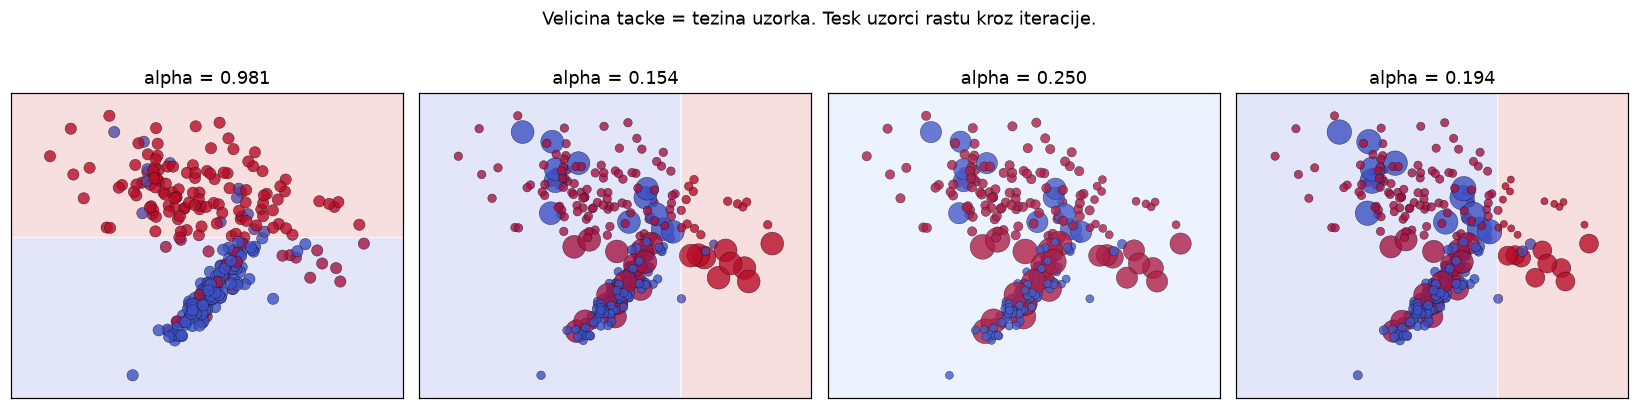

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
w2 = np.ones(n) / n
for a, (stump, alfa) in zip(ax, zip(modeli, alfe)):
    w2 = w2 / w2.sum()
    a.scatter(Xs[:, 0], Xs[:, 1], c=ys, s=w2 * n * 55, cmap="coolwarm",
              edgecolor="k", linewidth=0.3, alpha=0.8)
    XX, YY = np.meshgrid(np.linspace(Xs[:,0].min()-.5, Xs[:,0].max()+.5, 150),
                         np.linspace(Xs[:,1].min()-.5, Xs[:,1].max()+.5, 150))
    Z = stump.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    a.contourf(XX, YY, Z, alpha=0.16, cmap="coolwarm")
    a.set_title(f"alpha = {alfa:.3f}"); a.set_xticks([]); a.set_yticks([])
    w2 = w2 * np.exp(-alfa * ys_pm * stump.predict(Xs))
plt.suptitle("Velicina tacke = tezina uzorka. Tesk uzorci rastu kroz iteracije.", y=1.02)
plt.tight_layout(); plt.show()

### Gradient Boosting

Problem se posmatra kao **optimizacija funkcije gubitka**. Svaki novi model aproksimira
**negativni gradijent** greške prethodnih modela.

> Gradient Boosting pita: *„U kom smeru treba da pomerim model da bih najbrže smanjio
> grešku?"* — i taj smer je gradijent funkcije gubitka.

**Korak 1 — početni (bazni) model.** Najjednostavniji mogući: konstantna predikcija.
Za MSE to je **aritmetička sredina** ciljne promenljive.

**Korak 2 — učenje na grešci.** Za svaki uzorak računa se **rezidual**:
$$r^{(i)} = y^{(i)} - \hat y_1$$
Novo stablo ne uči cenu, nego **koliko treba korigovati prethodnu predikciju**.

**Korak 3 — kombinovanje (aditivni model):**
$$\hat y(x) = \hat y_1 + \alpha \cdot h_2(x)$$
gde je $\alpha$ **learning rate** (obično između 0 i 1).

Zatim se računaju novi reziduali $r_2 = y - \hat y_2$ i postupak se ponavlja.

> **Razlika u odnosu na AdaBoost:** kod AdaBoost-a se menjaju **težine uzoraka**, kod
> Gradient Boosting-a se direktno **uči greška** koristeći gradijent funkcije gubitka.

In [10]:
# rucni Gradient Boosting na regresiji — primer sa predavanja
from sklearn.tree import DecisionTreeRegressor
kuce = pd.DataFrame({
    "sobe": [5, 10, 6, 5], "grad": [0, 1, 2, 3], "starost": [30, 20, 20, 10],
    "cena": [1.50, 0.50, 0.25, 0.10],
})
Xk = kuce[["sobe", "grad", "starost"]].values
yk = kuce.cena.values

y1 = yk.mean()                                    # KORAK 1: bazni model = prosek
print(f"KORAK 1 — bazni model: y1 = prosek = {y1:.4f}\n")

r1 = yk - y1                                      # KORAK 2: reziduali
kuce["rezidual_r1"] = r1.round(4)
display(kuce)

h2 = DecisionTreeRegressor(max_depth=1).fit(Xk, r1)   # stablo uci REZIDUAL
kor = h2.predict(Xk)
print(f"\nKORAK 3 — korekcija drugog stabla: {kor.round(4)}")
for alfa in (1.0, 0.1):
    print(f"   alpha={alfa}: y2 = {y1:.4f} + {alfa}*korekcija = {(y1 + alfa*kor).round(4)}")
print(f"   stvarne cene:                      {yk}")

KORAK 1 — bazni model: y1 = prosek = 0.5875



,sobe,grad,starost,cena,rezidual_r1
0,5,0,30,1.50,0.9125
1,10,1,20,0.50,-0.0875
2,6,2,20,0.25,-0.3375
3,5,3,10,0.10,-0.4875



KORAK 3 — korekcija drugog stabla: [ 0.9125 -0.3042 -0.3042 -0.3042]
   alpha=1.0: y2 = 0.5875 + 1.0*korekcija = [1.5    0.2833 0.2833 0.2833]
   alpha=0.1: y2 = 0.5875 + 0.1*korekcija = [0.6788 0.5571 0.5571 0.5571]
   stvarne cene:                      [1.5  0.5  0.25 0.1 ]


In [11]:
# uticaj learning rate-a i broja stabala
print(f"{'learning_rate':>14} {'n_estimators':>14} {'CV tacnost':>12}")
print("-" * 44)
for lr in (0.01, 0.1, 1.0):
    for n_est in (50, 300):
        gb = GradientBoostingClassifier(learning_rate=lr, n_estimators=n_est, random_state=RS)
        print(f"{lr:>14} {n_est:>14} {cross_val_score(gb, X, y, cv=cv).mean():>12.4f}")
print("\n-> Mali learning_rate trazi vise stabala, ali daje stabilniji model.")

 learning_rate   n_estimators   CV tacnost
--------------------------------------------


          0.01             50       0.9192


          0.01            300       0.9508


           0.1             50       0.9455


           0.1            300       0.9561


           1.0             50       0.9561


           1.0            300       0.9508

-> Mali learning_rate trazi vise stabala, ali daje stabilniji model.


### XGBoost i LightGBM

**XGBoost** (Extreme Gradient Boosting) — brza, skalabilna i **regularizovana**
implementacija Gradient Boosting-a.

$$\text{XGBoost} = \text{Gradient Boosting} + \text{regularizacija} + \text{brzina} + \text{stabilnost}$$

Čest pobednik na ML takmičenjima.

**LightGBM** — veoma brza i memorijski efikasna implementacija. Gradi stabla **leaf-wise**,
što često daje bolju tačnost, ali može dovesti do overfittinga ako se ne ograniči dubina.
Efikasno rukuje kategorijskim i sparse podacima.

In [12]:
import time
print(f"{'model':<28} {'CV tacnost':>12} {'vreme':>9}")
print("-" * 52)
for ime, m in [("GradientBoosting (sklearn)", GradientBoostingClassifier(random_state=RS)),
               ("XGBoost", XGBClassifier(eval_metric="logloss", random_state=RS, n_jobs=-1)),
               ("AdaBoost", AdaBoostClassifier(random_state=RS))]:
    t0 = time.time()
    s = cross_val_score(m, X, y, cv=cv, n_jobs=1).mean()
    print(f"{ime:<28} {s:>12.4f} {time.time()-t0:>8.2f}s")

model                          CV tacnost     vreme
----------------------------------------------------


GradientBoosting (sklearn)         0.9491     1.18s


XGBoost                            0.9631     0.40s


AdaBoost                           0.9525     0.52s


## Random Forest

$$\text{Random Forest} = \text{Bagging} + \text{Decision Trees} + \text{Random Feature Subsets}$$

Pored bootstrap uzorkovanja, za **svaki čvor** stabla bira se **nasumičan podskup atributa**.
Time se sprečava da sva stabla koriste iste atribute i **povećava raznolikost** šume.

**Broj atributa po čvoru:**

| problem | broj atributa |
|---|---|
| klasifikacija | $\sqrt{d}$ |
| regresija | $d/3$ |

($d$ = ukupan broj atributa; u sklearn `max_features='sqrt'`)

> **Kombinovanje:** `RandomForestClassifier` u sklearn-u koristi **soft voting** (bez težina) —
> prosekuju se verovatnoće svih stabala:
> $$P(y=k \mid x) = \frac{1}{T}\sum_{t=1}^{T} P_t(y=k \mid x)$$

### ExtraTrees — još više slučajnosti

| | **Random Forest** | **ExtraTrees** |
|---|---|---|
| bootstrap | **da** | **ne** (koristi ceo skup) |
| izbor atributa | nasumičan podskup | nasumičan podskup |
| prag grananja | traži se **najbolji** split | prag se bira **nasumično** |

In [13]:
print(f"Broj atributa d = {X.shape[1]}")
print(f"   klasifikacija: sqrt(d) = {np.sqrt(X.shape[1]):.1f}")
print(f"   regresija    : d/3     = {X.shape[1]/3:.1f}\n")

print(f"{'model':<34} {'CV tacnost':>12}")
print("-" * 48)
for ime, m in [("Jedno stablo", DecisionTreeClassifier(random_state=RS)),
               ("Bagging (bez random features)",
                BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, random_state=RS, n_jobs=-1)),
               ("Random Forest (sqrt)",
                RandomForestClassifier(n_estimators=200, max_features="sqrt", random_state=RS, n_jobs=-1)),
               ("ExtraTrees",
                ExtraTreesClassifier(n_estimators=200, random_state=RS, n_jobs=-1))]:
    print(f"{ime:<34} {cross_val_score(m, X, y, cv=cv).mean():>12.4f}")

Broj atributa d = 30
   klasifikacija: sqrt(d) = 5.5
   regresija    : d/3     = 10.0

model                                CV tacnost
------------------------------------------------
Jedno stablo                             0.9104


Bagging (bez random features)            0.9561


Random Forest (sqrt)                     0.9543


ExtraTrees                               0.9684


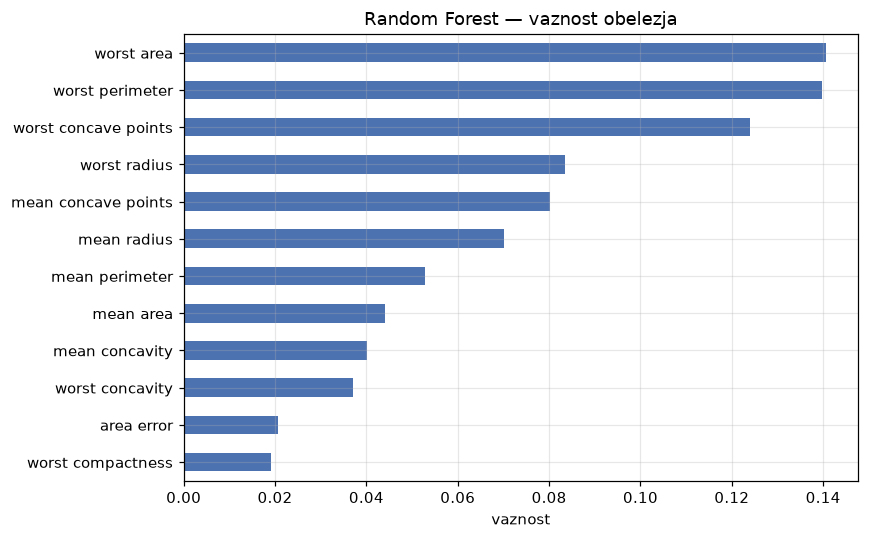

Napomena: ovo je MODEL-SPECIFICNA mera vaznosti (predavanje 13).


In [14]:
rf = RandomForestClassifier(n_estimators=300, random_state=RS, n_jobs=-1).fit(Xtr, ytr)
vazn = pd.Series(rf.feature_importances_, index=bc.feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
vazn.head(12)[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("vaznost"); ax.set_title("Random Forest — vaznost obelezja")
plt.tight_layout(); plt.show()
print("Napomena: ovo je MODEL-SPECIFICNA mera vaznosti (predavanje 13).")

## Stacking (slaganje modela)

Kombinovanje više modela pomoću **meta-modela**.

**Postupak:**

1. Treniraju se **bazni modeli** $h_1, \dots, h_T$ — mogu biti potpuno različiti tipovi
   (stablo, SVM, kNN, RF...)
2. Pravi se **novi skup podataka** gde svaki uzorak više nije originalni $x$, nego
   **vektor predikcija**:
   $$x_i' = \big[h_1(x_i), h_2(x_i), \dots, h_T(x_i)\big]$$
3. Na tim podacima se trenira **meta-model** (nivo 2), koji uči **kome da veruje u kojim
   situacijama**

> Meta-model **ne glasa — on uči kombinaciju.** Najčešće je jednostavan, npr. logistička
> regresija.

### Zašto je stacking sklon overfittingu

Ako se meta-model trenira na **istim** podacima na kojima su bazni modeli učeni, koristi
informacije koje bazni modeli već „znaju" → **data leakage** → visoka tačnost na treningu,
loše generalizovanje.

**Rešenje: k-fold cross-validation u stackingu.**

- skup se deli na $k$ foldova
- bazni modeli se treniraju $k$ puta, na $k-1$ foldova
- predikcije na **preostalom** foldu čuvaju se kao **out-of-fold (level-1)** predikcije
- meta-model se trenira **isključivo na out-of-fold predikcijama**
- na kraju se bazni modeli ponovo treniraju na celom skupu

> Meta-model **ne sme videti predikcije sa treninga**. Cross-validation sprečava data
> leakage u stackingu.

In [15]:
bazni = [
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=RS, n_jobs=-1)),
    ("svm", make_pipeline(StandardScaler(), SVC(probability=True, random_state=RS))),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(7))),
]
stack = StackingClassifier(bazni, final_estimator=LogisticRegression(max_iter=2000),
                           cv=5, n_jobs=-1)

print(f"{'model':<28} {'CV tacnost':>12}")
print("-" * 42)
for ime, m in bazni:
    print(f"{'  bazni: ' + ime:<28} {cross_val_score(m, X, y, cv=cv).mean():>12.4f}")
print("-" * 42)
print(f"{'Voting (soft)':<28} {cross_val_score(VotingClassifier(bazni, voting='soft', n_jobs=-1), X, y, cv=cv).mean():>12.4f}")
print(f"{'Stacking (cv=5)':<28} {cross_val_score(stack, X, y, cv=cv).mean():>12.4f}")

model                          CV tacnost
------------------------------------------
  bazni: lr                        0.9737


  bazni: rf                        0.9543
  bazni: svm                       0.9772
  bazni: knn                       0.9649
------------------------------------------


Voting (soft)                      0.9772


Stacking (cv=5)                    0.9754


In [16]:
# sta je meta-model naucio — kojim baznim modelima veruje
stack.fit(Xtr, ytr)
tezine = pd.Series(stack.final_estimator_.coef_[0], index=[i for i, _ in bazni])
print("Koeficijenti meta-modela (kome veruje):")
print(tezine.round(4).to_string())
print(f"\nTest tacnost stacking-a: {stack.score(Xte, yte):.4f}")

Koeficijenti meta-modela (kome veruje):
lr     2.6011
rf     2.1943
svm    2.2429
knn    1.5066

Test tacnost stacking-a: 0.9825


## Sažetak

| metoda | kako | smanjuje | ključna ideja |
|---|---|---|---|
| **Voting** | isti podaci, različiti modeli | varijansu | glasanje |
| **Bagging** | isti model, različiti (bootstrap) podaci | **varijansu** | prosečavanje |
| **Random Forest** | bagging + nasumični atributi | varijansu | dodatna raznolikost |
| **AdaBoost** | sekvencijalno, težine uzoraka | **bias** | fokus na teške primere |
| **Gradient Boosting** | sekvencijalno, uči rezidual | **bias** | optimizacija gubitka |
| **Stacking** | meta-model nad predikcijama | oboje | uči **kombinaciju** |

> **Ansambl radi samo ako modeli prave različite greške.** Raznolikost je ključna.